In [1]:
import pandas as pd
import random
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score
import numpy as np
from pathlib import Path
import os

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

class SpeechDataset(Dataset):
    def __init__(self, tokenizer, speeches, labels, max_length=512):
        self.encodings = tokenizer(speeches, truncation=True, padding=True, max_length=max_length)
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

def load_dataset(file_path, tokenizer, args):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"The file {file_path} does not exist.")
    
    df = pd.read_csv(file_path)
    speeches = df['target_sentence'].tolist()  # Column with speeches
    labels = df['empirical_evidence'].tolist()  # Binary label for empirical evidence
    dataset = SpeechDataset(tokenizer, speeches, labels)
    return dataset


def evaluate_model(args, model, test_dataset):
    dataloader = DataLoader(test_dataset, batch_size=args.batch_size)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []
    for batch in dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        with torch.no_grad():
            outputs = model(**batch)

        logits = outputs.logits
        predictions = torch.argmax(logits, dim=-1)
        labels = batch['labels']
        all_labels += labels.cpu().tolist()
        all_preds += predictions.cpu().tolist()

    accuracy = accuracy_score(all_labels, all_preds)
    return accuracy

def main(args):
    tokenizer = AutoTokenizer.from_pretrained(args.base_model)
    train_dataset = load_dataset(args.train_file, tokenizer, args)
    test_dataset = load_dataset(args.test_file, tokenizer, args)

    model = AutoModelForSequenceClassification.from_pretrained(args.base_model, num_labels=2)

    training_args = TrainingArguments(
        output_dir=args.output_dir,
        num_train_epochs=args.epochs,
        per_device_train_batch_size=args.batch_size,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        logging_dir=args.logging_dir,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
    )

    trainer.train()

    acc = evaluate_model(args, model, test_dataset)
    print(f"Test Accuracy: {acc}")

if __name__ == '__main__':
    import argparse
    parser = argparse.ArgumentParser()
    parser.add_argument("--train_file", type=str, default="train.csv")
    parser.add_argument("--test_file", type=str, default="test.csv")
    parser.add_argument("--base_model", type=str, default="roberta-base")
    parser.add_argument("--output_dir", type=str, default="./model_output")
    parser.add_argument("--epochs", type=int, default=5)
    parser.add_argument("--batch_size", type=int, default=16)
    parser.add_argument("--logging_dir", type=str, default="./logs")
    parser.add_argument("--seed", type=int, default=42)
    args = parser.parse_args()

    set_seed(args.seed)
    main(args)


usage: ipykernel_launcher.py [-h] [--train_file TRAIN_FILE] [--test_file TEST_FILE] [--base_model BASE_MODEL]
                             [--output_dir OUTPUT_DIR] [--epochs EPOCHS] [--batch_size BATCH_SIZE]
                             [--logging_dir LOGGING_DIR] [--seed SEED]
ipykernel_launcher.py: error: unrecognized arguments: -f C:\Users\USER\AppData\Roaming\jupyter\runtime\kernel-44a2e3ae-943f-435a-905d-3efd3ca59cf4.json


SystemExit: 2

C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
from pathlib import Path
import os
import pandas as pd

# path = "C:\\Users\\USER\\Documents\\empirical_evidence_corren"
path = "C:\\Users\\USER\\OneDrive - Tel-Aviv University\\Documents\\empirical_evidence_corren"
# Set the project root directory
PROJECT_ROOT = Path(path)
# Function to construct paths relative to the project root
def project_path(*args):
    return PROJECT_ROOT.joinpath(*args)
    

#main_df = pd.read_csv(project_path("hearings_testing","sample_comparison", "RA_merged_with_agreement.csv"))

#main_df['empirical_binary'] = main_df['empirical_binary'].str.strip().str.lower().apply(lambda x: 1 if x in ('yes', 'y') else 0)

In [13]:
# Assuming 'df' is your DataFrame
test_df = main_df.sample(frac=0.2, random_state=42)  # 10% sample for test
train_df = main_df.drop(test_df.index)  # Remaining 90% for train

# Save the datasets to CSV files
test_df.to_csv(project_path("scripts","classifier_categories","test.csv"), index=False)
train_df.to_csv(project_path("scripts","classifier_categories","train.csv"), index=False)

print("Test set saved to 'test.csv' with", len(test_df), "rows.")
print("Train set saved to 'train.csv' with", len(train_df), "rows.")

Test set saved to 'test.csv' with 389 rows.
Train set saved to 'train.csv' with 1556 rows.


In [8]:
# Clean the 'Category' column: strip spaces and convert to lowercase
main_df['empirical_category_cleaned'] = main_df['empirical_category'] \
    .str.replace(' ', '') \
    .str.replace('.', '') \
    .str.lower()

# Split the cleaned 'Category' column by comma
main_df['empirical_category_split'] = main_df['empirical_category_cleaned'].str.split(',')

main_df['empirical_category_split'] = main_df['empirical_category_split'].apply(
    lambda x: x if isinstance(x, (list, set)) else []
)

# Get the list of all unique categories
unique_categories = set()

# Safely update unique_categories with iterables
main_df['empirical_category_split'].apply(lambda x: unique_categories.update(x))


# Create one-hot encoded columns
for category in unique_categories:
    main_df[f'category_{category}'] = main_df['empirical_category_split'].apply(
        lambda x: 1 if category in x else 0
    )

# Drop the temporary columns
main_df.drop(['empirical_category_cleaned', 'empirical_category_split'], axis=1, inplace=True)

In [11]:
main_df

,congress_rater1,committee_code2_rater1,title_rater1,file_name_rater1,thomas_name_rater1,govtrack_rater1,speech_rater1,rownumber_rater1,gscore_rater1,powercmt_rater1,...,category_,category_historical,category_<none>,category_statistical,category_qualitative,category_monetary,category_correlational,category_descriptive,category_causal,category_testimonial
0,109,HSSY,NASA'S FISCAL YEAR 2006 BUDGET PROPOSAL,CHRG-109hhrg98564.txt,"Boehlert, Sherwood",400035,We have a crisis. Someone stole the Chairman's...,339170,64.704351,0,...,0,0,0,0,0,0,0,0,0,0
1,109,HSSY,NASA'S FISCAL YEAR 2006 BUDGET PROPOSAL,CHRG-109hhrg98564.txt,"Boehlert, Sherwood",400035,We have a crisis. Someone stole the Chairman's...,339170,64.704351,0,...,0,0,0,0,0,0,0,0,0,0
2,109,HSSY,NASA'S FISCAL YEAR 2006 BUDGET PROPOSAL,CHRG-109hhrg98564.txt,"Boehlert, Sherwood",400035,We have a crisis. Someone stole the Chairman's...,339170,64.704351,0,...,0,0,0,0,0,0,0,0,0,0
3,109,HSSY,NASA'S FISCAL YEAR 2006 BUDGET PROPOSAL,CHRG-109hhrg98564.txt,"Boehlert, Sherwood",400035,We have a crisis. Someone stole the Chairman's...,339170,64.704351,0,...,0,0,0,0,0,0,0,0,0,0
4,109,HSSY,NASA'S FISCAL YEAR 2006 BUDGET PROPOSAL,CHRG-109hhrg98564.txt,"Boehlert, Sherwood",400035,We have a crisis. Someone stole the Chairman's...,339170,64.704351,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1940,111,HSBA,IMPLEMENTATION OF HIGHER FHA LOAN FEES AND PEN...,CHRG-111hhrg62681.txt,"Frank, Barney",400140,The time has expired. I don't want to get into...,617304,33.024328,0,...,0,0,0,0,0,0,0,0,0,0
1941,111,HSBA,IMPLEMENTATION OF HIGHER FHA LOAN FEES AND PEN...,CHRG-111hhrg62681.txt,"Frank, Barney",400140,The time has expired. I don't want to get into...,617304,33.024328,0,...,0,0,0,0,0,0,0,0,0,0
1942,111,HSBA,IMPLEMENTATION OF HIGHER FHA LOAN FEES AND PEN...,CHRG-111hhrg62681.txt,"Frank, Barney",400140,The time has expired. I don't want to get into...,617304,33.024328,0,...,0,0,0,0,0,0,0,0,0,0
1943,111,HSBA,IMPLEMENTATION OF HIGHER FHA LOAN FEES AND PEN...,CHRG-111hhrg62681.txt,"Frank, Barney",400140,The time has expired. I don't want to get into...,617304,33.024328,0,...,0,0,0,0,0,0,0,0,0,0


# load fine tuned Roberta

In [3]:
from transformers import AutoTokenizer

# Specify the base model used for training (e.g., roberta-base)
base_model = "roberta-base"  # Replace with the model you used

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(base_model)

model_directory = project_path("scripts","classifier_categories","model_output","checkpoint-490")  # Replace with the actual path

# Save the tokenizer files to your checkpoint directory
tokenizer.save_pretrained(model_directory)


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

C:\Users\USER\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\USER\.cache\huggingface\hub\models--roberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

('C:\\Users\\USER\\OneDrive - Tel-Aviv University\\Documents\\empirical_evidence_corren\\scripts\\classifier_categories\\model_output\\checkpoint-490\\tokenizer_config.json',
 'C:\\Users\\USER\\OneDrive - Tel-Aviv University\\Documents\\empirical_evidence_corren\\scripts\\classifier_categories\\model_output\\checkpoint-490\\special_tokens_map.json',
 'C:\\Users\\USER\\OneDrive - Tel-Aviv University\\Documents\\empirical_evidence_corren\\scripts\\classifier_categories\\model_output\\checkpoint-490\\vocab.json',
 'C:\\Users\\USER\\OneDrive - Tel-Aviv University\\Documents\\empirical_evidence_corren\\scripts\\classifier_categories\\model_output\\checkpoint-490\\merges.txt',
 'C:\\Users\\USER\\OneDrive - Tel-Aviv University\\Documents\\empirical_evidence_corren\\scripts\\classifier_categories\\model_output\\checkpoint-490\\added_tokens.json',
 'C:\\Users\\USER\\OneDrive - Tel-Aviv University\\Documents\\empirical_evidence_corren\\scripts\\classifier_categories\\model_output\\checkpoint-490

In [4]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Load the tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(model_directory, local_files_only=True)
model = AutoModelForSequenceClassification.from_pretrained(model_directory, local_files_only=True)

# Move the model to the appropriate device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()  # Set the model to evaluation mode

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

In [5]:
texts = ["But you will not disagree, there was a chemical cesspool and more or less some of our soldiers were exposed to some or all of those agents.",
         "Now, the question I am asking you is, is it not true that the Registry did not ask this question until 1995?",
        "I don't think NASA should be our top budget priority, either in this committee or in this Congress.",
        "it is a value based judgment whether to enact this law"]

inputs = tokenizer(texts, padding=True, truncation=True, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    predictions = torch.argmax(logits, dim=-1)
    probabilities = torch.softmax(logits, dim=-1).cpu().numpy()  # Get probabilities

print("Predictions:", predictions.cpu().tolist())
print("Probabbilities:", probabilities[:, 1].tolist())

Predictions: [7, 7, 7, 7]
Probabbilities: [0.0029848867561668158, 0.0715731531381607, 0.07309789210557938, 0.07367593050003052]


              precision    recall  f1-score   support

           0      0.945     0.955     0.950      1720
           1      0.626     0.573     0.599       225

    accuracy                          0.911      1945
   macro avg      0.786     0.764     0.774      1945
weighted avg      0.908     0.911     0.909      1945

AUC-ROC: 0.921


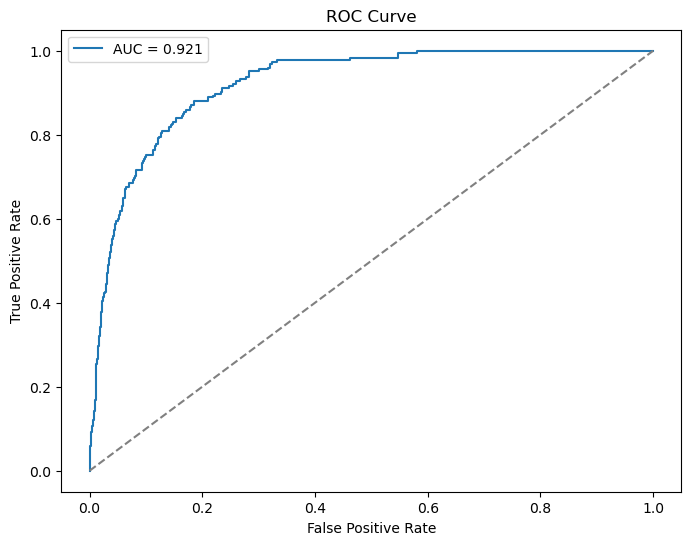

In [93]:
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

df = pd.read_csv(project_path("hearings_testing", "sample_comparison","RA_merged_with_agreement.csv"))
# df['empirical_binary'] = df['empirical_binary'].str.strip().str.lower().apply(lambda x: 1 if x in ('yes', 'y') else 0)

# Tokenize the input texts
texts = df['target_sentence'].tolist()
inputs = tokenizer(texts, padding=True, truncation=True, return_tensors="pt", max_length=512).to(device)

# Perform predictions
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    probabilities = torch.softmax(logits, dim=-1).cpu().numpy()  # Get probabilities
    predictions = torch.argmax(logits, dim=-1).cpu().tolist()  # Convert predictions to a list

# Compare predictions to true labels
true_labels = df['empirical_binary'].tolist()
# Generate classification report
report = classification_report(true_labels, predictions, digits=3)
print(report)

# Calculate AUC-ROC
if len(set(true_labels)) == 2:  # Ensure binary classification
    auc = roc_auc_score(true_labels, probabilities[:, 1])  # Use probabilities for the positive class
    print(f"AUC-ROC: {auc:.3f}")

    # Plot ROC Curve
    fpr, tpr, _ = roc_curve(true_labels, probabilities[:, 1])
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()
else:
    print("AUC-ROC is only applicable for binary classification.")

# category classifier

In [20]:
from transformers import AutoTokenizer

# Specify the base model used for training (e.g., roberta-base)
base_model = "roberta-base"  # Replace with the model you used

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(base_model)

model_directory = project_path("scripts","classifier_categories","model_output","checkpoint-490")  # Replace with the actual path

# Save the tokenizer files to your checkpoint directory
tokenizer.save_pretrained(model_directory)


from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Load the tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(model_directory, local_files_only=True)
model = AutoModelForSequenceClassification.from_pretrained(model_directory, local_files_only=True)

# Move the model to the appropriate device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()  # Set the model to evaluation mode

C:\Users\mitha\anaconda3\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [22]:
def predict_labels(texts, model, tokenizer, threshold=0.5, max_length=512):
    """
    Predict multi-label categories for a list of texts.

    Args:
        texts (list of str): List of input sentences.
        model (AutoModelForSequenceClassification): The fine-tuned model.
        tokenizer (AutoTokenizer): Tokenizer used with the model.
        threshold (float): Threshold for determining label presence (default: 0.5).
        max_length (int): Maximum sequence length for tokenization.

    Returns:
        List of dictionaries with label predictions and probabilities.
    """
    # Tokenize the input texts
    encodings = tokenizer(
        texts,
        truncation=True,
        padding=True,
        max_length=max_length,
        return_tensors="pt"
    )

    # Move data to the same device as the model
    input_ids = encodings["input_ids"].to(model.device)
    attention_mask = encodings["attention_mask"].to(model.device)

    # Perform inference
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probabilities = torch.sigmoid(logits).cpu().numpy()

    # Apply threshold to get binary predictions
    predictions = (probabilities > threshold).astype(int)

    # Define label names (match the order of one-hot encoding used in training)
    label_names = [
        "historical", "correlational", "causal", "monetary",
        "qualitative", "testimonial", "statistical", "descriptive"
    ]

    # Create output structure
    results = []
    for text, probs, preds in zip(texts, probabilities, predictions):
        results.append({
            "text": text,
            "labels": [label_names[i] for i in range(len(preds)) if preds[i] == 1],
            "probabilities": {label_names[i]: probs[i] for i in range(len(probs))}
        })

    return results


In [32]:
from torch.utils.data import Dataset, DataLoader
import torch
from sklearn.metrics import f1_score, accuracy_score
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification

class EvaluationDataset(Dataset):
    def __init__(self, tokenizer, texts, labels, max_length=512):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=max_length)
        self.labels = labels  # One-hot encoded labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

    def __len__(self):
        return len(self.labels)

def evaluate_model_on_dataset(model, dataloader, threshold=0.5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    for batch in dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            probabilities = torch.sigmoid(logits)  # Convert logits to probabilities

        # Append predictions and ground truth
        all_preds.append((probabilities > threshold).cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    # Combine all batches
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    # Calculate metrics
    f1 = f1_score(all_labels, all_preds, average='macro')
    accuracy = accuracy_score(all_labels, all_preds)
    
    return {"f1_score": f1, "accuracy": accuracy}

# Assuming `df` is your preloaded dataset
def evaluate_with_preloaded_data(df, model, tokenizer, batch_size=16, threshold=0.5):
    # Extract texts and labels from the DataFrame
    texts = df['target_sentence'].tolist()
    labels = df[['category_historical', 'category_correlational', 'category_causal',
                 'category_monetary', 'category_qualitative', 'category_testimonial',
                 'category_statistical', 'category_descriptive']].values.tolist()

    # Create the dataset and dataloader
    eval_dataset = EvaluationDataset(tokenizer, texts, labels)
    eval_dataloader = DataLoader(eval_dataset, batch_size=batch_size)

    # Evaluate the model
    metrics = evaluate_model_on_dataset(model, eval_dataloader, threshold=threshold)
    return metrics


In [34]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader

# Load the model and tokenizer
model_directory = project_path("scripts","classifier_categories","model_output","checkpoint-490")  # Replace with the actual path
tokenizer = AutoTokenizer.from_pretrained(model_directory, local_files_only=True)
model = AutoModelForSequenceClassification.from_pretrained(model_directory, local_files_only=True)

# Evaluate the model
metrics = evaluate_with_preloaded_data(main_df, model, tokenizer, batch_size=16, threshold=0.5)

print(f"F1 Score: {metrics['f1_score']}")
print(f"Accuracy: {metrics['accuracy']}")


F1 Score: 0.17614140070921985
Accuracy: 0.9367609254498714


# compare Roberta scores for Or and our data

In [43]:
from pathlib import Path
import os
import glob

import pandas as pd
import spacy
from tqdm.auto import tqdm

# =======================================================
# 0. PROJECT PATHS
# =======================================================
path = r"C:\Users\USER\OneDrive - Tel-Aviv University\Documents\empirical_evidence_corren"
PROJECT_ROOT = Path(path)

def project_path(*args):
    return PROJECT_ROOT.joinpath(*args)

data_dir = project_path("data", "or_kroyzer_data")
print("Data directory:", data_dir)

# Where to save all sentence-level data (no classification yet)
sentences_file = project_path("hearings_testing", "all_sentences_with_meta.csv")
sentences_file.parent.mkdir(parents=True, exist_ok=True)

# Remove old file if you want a fresh run
if sentences_file.exists():
    print("Removing existing sentences file...")
    sentences_file.unlink()

# =======================================================
# 1. SPACY SENTENCE SPLITTING (LIGHTWEIGHT, LARGE-TEXT SAFE)
# =======================================================
nlp = spacy.blank("en")
nlp.max_length = 5_000_000  # allow very long speeches
if "sentencizer" not in nlp.pipe_names:
    nlp.add_pipe("sentencizer")

def split_into_sentences(text: str):
    if not isinstance(text, str):
        return []
    doc = nlp(text)
    return [sent.text.strip() for sent in doc.sents if sent.text.strip()]

# =======================================================
# 2. READ ALL CSVs, KEEP ONLY NEEDED COLUMNS, SPLIT INTO SENTENCES
# =======================================================
csv_files = sorted(glob.glob(str(data_dir / "*.csv")))
print("Found CSVs:")
for f in csv_files:
    print("  ", f)

# only keep columns we really care about
cols_needed = ["speech", "speaker_type", "thomas_name", "title_hearings","chamber"]

sentence_dfs = []
chunksize = 2000  # adjust based on RAM

for file_path in tqdm(csv_files, desc="Files"):
    file_name = os.path.basename(file_path)
    print(f"\n=== Processing file: {file_name} ===")

    for chunk in pd.read_csv(
        file_path,
        chunksize=chunksize,
        low_memory=False,
    ):
        if "speech" not in chunk.columns:
            continue

        # keep subset of columns (if present)
        keep = [c for c in cols_needed if c in chunk.columns]
        chunk = chunk[keep].copy()

        # add source file for tracking
        chunk["source_file"] = file_name

        # split into sentences
        chunk["sentences"] = chunk["speech"].apply(split_into_sentences)

        # explode
        df_sent = chunk.explode("sentences", ignore_index=True)
        df_sent = df_sent.rename(columns={"sentences": "sentence"})

        # drop empty sentences
        df_sent = df_sent[
            df_sent["sentence"].notna() & (df_sent["sentence"].str.len() > 0)
        ]

        if df_sent.empty:
            continue

        sentence_dfs.append(df_sent)

# concatenate all sentences into one DataFrame
df_sentences_all = pd.concat(sentence_dfs, ignore_index=True)

print("\nTotal sentences:", len(df_sentences_all))
print("\nSample rows:")
print(df_sentences_all.head(10))

print("\nSpeaker_type distribution:")
print(df_sentences_all["speaker_type"].value_counts(dropna=False))

# save to disk so we can reuse without recomputing
df_sentences_all.to_csv(sentences_file, index=False)
print("\n✅ Saved all sentences with metadata to:")
print(sentences_file)


Data directory: C:\Users\USER\OneDrive - Tel-Aviv University\Documents\empirical_evidence_corren\data\or_kroyzer_data
Removing existing sentences file...
Found CSVs:
   C:\Users\USER\OneDrive - Tel-Aviv University\Documents\empirical_evidence_corren\data\or_kroyzer_data\adh.csv
   C:\Users\USER\OneDrive - Tel-Aviv University\Documents\empirical_evidence_corren\data\or_kroyzer_data\ash.csv
   C:\Users\USER\OneDrive - Tel-Aviv University\Documents\empirical_evidence_corren\data\or_kroyzer_data\bgh.csv
   C:\Users\USER\OneDrive - Tel-Aviv University\Documents\empirical_evidence_corren\data\or_kroyzer_data\bgs.csv
   C:\Users\USER\OneDrive - Tel-Aviv University\Documents\empirical_evidence_corren\data\or_kroyzer_data\bhu.csv
   C:\Users\USER\OneDrive - Tel-Aviv University\Documents\empirical_evidence_corren\data\or_kroyzer_data\cgr.csv
   C:\Users\USER\OneDrive - Tel-Aviv University\Documents\empirical_evidence_corren\data\or_kroyzer_data\csc.csv
   C:\Users\USER\OneDrive - Tel-Aviv Univer

Files:   0%|          | 0/40 [00:00<?, ?it/s]


=== Processing file: adh.csv ===

=== Processing file: ash.csv ===

=== Processing file: bgh.csv ===

=== Processing file: bgs.csv ===

=== Processing file: bhu.csv ===

=== Processing file: cgr.csv ===

=== Processing file: csc.csv ===

=== Processing file: cst.csv ===

=== Processing file: ecj.csv ===

=== Processing file: eec.csv ===

=== Processing file: esr.csv ===

=== Processing file: fns.csv ===

=== Processing file: foa.csv ===

=== Processing file: for.csv ===

=== Processing file: hag.csv ===

=== Processing file: hap.csv ===

=== Processing file: hec.csv ===

=== Processing file: hel.csv ===

=== Processing file: hew.csv ===

=== Processing file: hfs.csv ===

=== Processing file: hjh.csv ===

=== Processing file: hnr.csv ===

=== Processing file: hsc.csv ===

=== Processing file: hsg.csv ===

=== Processing file: hti.csv ===

=== Processing file: ias.csv ===

=== Processing file: ish.csv ===

=== Processing file: iss.csv ===

=== Processing file: nar.csv ===

=== Processin

In [47]:
def normalize_chamber(x):
    if not isinstance(x, str):
        return None
    x = x.lower()
    if "house" in x and "senate" not in x:
        return "House"
    if "senate" in x and "house" not in x:
        return "Senate"
    if "joint" in x:
        return "Joint"
    return "Other"

df_sentences_all["chamber_clean"] = df_sentences_all["chamber"].apply(normalize_chamber)

In [56]:
# df_sentences_all = pd.read_csv(sentences_file, low_memory=False)
#df_sentences_all.head()
#df_sentences_all["chamber_clean"].value_counts()


df_to_classify = df_sentences_all[df_sentences_all["speaker_type"] == "member"].reset_index(drop=True)
print("Filtered sentences for members:", len(df_to_classify))

#filter rows where chamber == "House of Representatives" | "U.S. House of Representatives"
df_to_classify = df_to_classify[df_to_classify["chamber_clean"] == "House"].reset_index(drop=True)
print("Filtered sentences for House:", len(df_to_classify))


Filtered sentences for members: 5149100
Filtered sentences for House: 5118951


In [51]:
# from pathlib import Path
# import pandas as pd
# import torch
# from tqdm.auto import tqdm
# from transformers import AutoTokenizer, AutoModelForSequenceClassification

# # =======================================================
# # 0. Paths
# # =======================================================
# path = r"C:\Users\USER\OneDrive - Tel-Aviv University\Documents\empirical_evidence_corren"
# PROJECT_ROOT = Path(path)

# def project_path(*args):
#     return PROJECT_ROOT.joinpath(*args)

# sentences_file = project_path("hearings_testing", "all_sentences_with_meta.csv")
# predictions_file = project_path("hearings_testing", "sentence_predictions_all.csv")

# # =======================================================
# # 1. Load sentence data
# # =======================================================
# df_sentences_all = pd.read_csv(sentences_file, low_memory=False)
# print("Loaded sentences:", len(df_sentences_all))

# # Filter rows where speaker_type == "member"
# df_to_classify = df_sentences_all[df_sentences_all["speaker_type"] == "member"].reset_index(drop=True)
# print("Filtered sentences for members:", len(df_to_classify))

# #filter rows where chamber == "House of Representatives" | "U.S. House of Representatives"
# df_to_classify = df_to_classify[df_to_classify["chamber"] == "House of Representatives"].reset_index(drop=True)
# print("Filtered sentences for House:", len(df_to_classify))

# # =======================================================
# # 2. Clean sentence column (remove NaNs, empty strings, etc.)
# # =======================================================
# # Drop NaN and empty sentences
# df_to_classify["sentence"] = df_to_classify["sentence"].astype(str).str.strip()
# df_to_classify = df_to_classify[df_to_classify["sentence"] != ""].reset_index(drop=True)

# print(f"Sentences after cleaning: {len(df_to_classify)}")

# # Optionally, display a sample to verify
# print("\nSample sentences to check after cleaning:")
# print(df_to_classify["sentence"].head(10))

# # =======================================================
# # 3. Load model & tokenizer
# # =======================================================
# model_directory = project_path("hearings_testing", "model_output", "checkpoint-760")
# print("Model directory:", model_directory)

# tokenizer = AutoTokenizer.from_pretrained(model_directory, local_files_only=True)
# model = AutoModelForSequenceClassification.from_pretrained(model_directory, local_files_only=True)

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print("Using device:", device)
# model.to(device)
# model.eval()

# id2label = getattr(model.config, "id2label", None)

# # =======================================================
# # 4. Classification helper
# # =======================================================
# def classify_sentences(
#     df: pd.DataFrame,
#     text_column: str = "sentence",
#     batch_size: int = 32,
#     max_length: int = 256,
# ) -> pd.DataFrame:
#     df = df.reset_index(drop=True).copy()
#     n = len(df)
#     print("Classifying", n, "sentences")

#     if n == 0:
#         return df

#     df["pred_label_id"] = None
#     df["pred_label"] = None
#     df["pred_confidence"] = None

#     softmax = torch.nn.Softmax(dim=-1)
#     n_batches = (n + batch_size - 1) // batch_size

#     for start in tqdm(range(0, n, batch_size), total=n_batches, desc="Batches"):
#         end = min(start + batch_size, n)
#         batch_texts = df[text_column].iloc[start:end].tolist()

#         encodings = tokenizer(
#             batch_texts,
#             padding=True,
#             truncation=True,
#             max_length=max_length,
#             return_tensors="pt",
#         )
#         encodings = {k: v.to(device) for k, v in encodings.items()}

#         with torch.no_grad():
#             outputs = model(**encodings)
#             logits = outputs.logits
#             probs = softmax(logits)

#         batch_pred_ids = probs.argmax(dim=-1).cpu().tolist()
#         batch_pred_probs = probs.max(dim=-1).values.cpu().tolist()

#         if id2label:
#             batch_pred_labels = [id2label[i] for i in batch_pred_ids]
#         else:
#             batch_pred_labels = [str(i) for i in batch_pred_ids]

#         # Update the rows with predictions
#         df.iloc[start:end, df.columns.get_loc("pred_label_id")] = batch_pred_ids
#         df.iloc[start:end, df.columns.get_loc("pred_label")] = batch_pred_labels
#         df.iloc[start:end, df.columns.get_loc("pred_confidence")] = batch_pred_probs

#     return df

# # =======================================================
# # 5. Run classification & save
# # =======================================================
# df_classified = classify_sentences(df_to_classify, text_column="sentence", batch_size=32)

# # Save to file
# df_classified.to_csv(predictions_file, index=False)
# print("\n✅ Saved predictions to:")
# print(predictions_file)


In [65]:
from pathlib import Path
import pandas as pd
import torch
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# =======================================================
# 0. Paths
# =======================================================
path = r"C:\Users\USER\OneDrive - Tel-Aviv University\Documents\empirical_evidence_corren"
PROJECT_ROOT = Path(path)

def project_path(*args):
    return PROJECT_ROOT.joinpath(*args)

sentences_file = project_path("hearings_testing", "all_sentences_with_meta.csv")
predictions_file = project_path("hearings_testing", "sentence_predictions_all.csv")

# =======================================================
# 1. Load sentence data + FILTER (member + House)
# =======================================================
df_sentences_all = pd.read_csv(sentences_file, low_memory=False)
print("Loaded sentences:", len(df_sentences_all))

def clean_chamber(ch):
    if not isinstance(ch, str):
        return "Other"
    ch = ch.lower().strip()

    if "joint" in ch:
        return "Joint"
    if "commission" in ch:
        return "Commission"
    if "legislative branch" in ch:
        return "Legislative Branch"

    if "house" in ch and "senate" not in ch:
        return "House"
    if "senate" in ch and "house" not in ch:
        return "Senate"

    return "Other"

df_sentences_all["chamber_clean"] = df_sentences_all["chamber"].apply(clean_chamber)

# Filter
df_to_classify = df_sentences_all[
    (df_sentences_all["speaker_type"] == "member") &
    (df_sentences_all["chamber_clean"] == "House")
].copy()

print("Filtered (member + House):", len(df_to_classify))

# Clean sentence
df_to_classify = df_to_classify[df_to_classify["sentence"].notna()].copy()
df_to_classify["sentence"] = df_to_classify["sentence"].astype(str).str.strip()
df_to_classify = df_to_classify[df_to_classify["sentence"] != ""].copy()
df_to_classify = df_to_classify.reset_index(drop=True)

print("After cleaning sentence:", len(df_to_classify))

Loaded sentences: 9612484
Filtered (member + House): 5118951
After cleaning sentence: 5118951
Sample sentences: ['I call order Committee House Administration for todays Committee meeting quorum is present can proceed meeting record will remain open for 5 legislative days members might submit material wish included', 'numbers items docket today Actually I think eight different items going talking about transferring House Safe Program updating Voucher Documentation Standards updating National Gallery Art boundaries Gold Star Families Voices Act reauthorizing sound recording film preservation programs Library Congress among other items permitting United States Capitol Police accept certain property other Federal agencies dispose certain property in possession Library Modernization Act amending Federal Election Campaign Act 1971 Committee is charged oversight operations House which includes responsibility ensure institution remains open accountable American taxpayers Additionally course st

In [66]:
# =======================================================
# 2. Load model & tokenizer
# =======================================================
model_directory = project_path("hearings_testing", "model_output", "checkpoint-760")
print("Model directory:", model_directory)

tokenizer = AutoTokenizer.from_pretrained(model_directory, local_files_only=True)
model = AutoModelForSequenceClassification.from_pretrained(model_directory, local_files_only=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
model.to(device)
model.eval()

id2label = getattr(model.config, "id2label", None)

# =======================================================
# 3. Classification helper
# =======================================================
def classify_sentences(
    df: pd.DataFrame,
    text_column: str = "sentence",
    batch_size: int = 32,
    max_length: int = 256,
) -> pd.DataFrame:
    df = df.reset_index(drop=True).copy()
    n = len(df)
    print("Classifying", n, "sentences")

    if n == 0:
        return df

    df["pred_label_id"] = None
    df["pred_label"] = None
    df["pred_confidence"] = None

    softmax = torch.nn.Softmax(dim=-1)
    n_batches = (n + batch_size - 1) // batch_size

    for start in tqdm(range(0, n, batch_size), total=n_batches, desc="Batches"):
        end = min(start + batch_size, n)
        batch_texts = df[text_column].iloc[start:end].astype(str).tolist()

        encodings = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        encodings = {k: v.to(device) for k, v in encodings.items()}

        with torch.no_grad():
            outputs = model(**encodings)
            logits = outputs.logits
            probs = softmax(logits)

        batch_pred_ids = probs.argmax(dim=-1).cpu().tolist()
        batch_pred_probs = probs.max(dim=-1).values.cpu().tolist()

        if id2label:
            batch_pred_labels = [id2label[i] for i in batch_pred_ids]
        else:
            batch_pred_labels = [str(i) for i in batch_pred_ids]

        df.iloc[start:end, df.columns.get_loc("pred_label_id")] = batch_pred_ids
        df.iloc[start:end, df.columns.get_loc("pred_label")] = batch_pred_labels
        df.iloc[start:end, df.columns.get_loc("pred_confidence")] = batch_pred_probs

    return df

# =======================================================
# 4. Run classification & save (OVERWRITE)
# =======================================================
df_classified = classify_sentences(df_to_classify, text_column="sentence", batch_size=32)

df_classified.to_csv(predictions_file, index=False)
print("\n✅ Saved predictions to:")
print(predictions_file)

Model directory: C:\Users\USER\OneDrive - Tel-Aviv University\Documents\empirical_evidence_corren\hearings_testing\model_output\checkpoint-760
Using device: cpu
Classifying 5118951 sentences


Batches:   0%|          | 0/159968 [00:00<?, ?it/s]


✅ Saved predictions to:
C:\Users\USER\OneDrive - Tel-Aviv University\Documents\empirical_evidence_corren\hearings_testing\sentence_predictions_all.csv


In [64]:
# --- 1) Define your current universe (filtered dataset) ---
df_to_classify = df_sentences_all[df_sentences_all["speaker_type"] == "member"].copy()
df_to_classify = df_to_classify[df_to_classify["chamber_clean"] == "House"].copy()

#merge_cols_candidate = ["source_file", "thomas_name", "title_hearings", "speech", "sentence"]
merge_cols = [c for c in merge_cols_candidate if c in df_to_classify.columns and c in df_final.columns]

print("Merging on:", merge_cols)

df_merged = df_to_classify.merge(
    df_final[merge_cols + ["pred_label_id","pred_label","pred_confidence"]],
    on=merge_cols,
    how="left",
    validate="many_to_one"
)

print("Universe rows:", len(df_to_classify))
print("Merged rows:", len(df_merged))
print("Missing predictions:", df_merged["pred_label_id"].isna().sum())


Merging on: ['source_file', 'thomas_name', 'title_hearings', 'sentence']


MergeError: Merge keys are not unique in right dataset; not a many-to-one merge

In [63]:
[c for c in df_to_classify.columns if "id" in c.lower() or "index" in c.lower() or "turn" in c.lower()]


[]

In [67]:
df_classified

,speech,speaker_type,thomas_name,title_hearings,chamber,source_file,sentence,chamber_clean,pred_label_id,pred_label,pred_confidence
0,I call order Committee House Administration f...,member,"Miller, Candice S","Markup on Committee Resolution 114, H.R. 5160,...",House of Representatives,adh.csv,I call order Committee House Administration fo...,House,0,LABEL_0,0.995831
1,numbers items docket today Actually I think e...,member,"Miller, Candice S","Markup on Committee Resolution 114, H.R. 5160,...",House of Representatives,adh.csv,numbers items docket today Actually I think ei...,House,0,LABEL_0,0.918267
2,Thank Madam Chairman Just say thank for heari...,member,"Brady, Robert","Markup on Committee Resolution 114, H.R. 5160,...",House of Representatives,adh.csv,Thank Madam Chairman Just say thank for hearin...,House,0,LABEL_0,0.995961
3,other Member wish make opening statement Okay...,member,"Miller, Candice S","Markup on Committee Resolution 114, H.R. 5160,...",House of Representatives,adh.csv,other Member wish make opening statement Okay ...,House,0,LABEL_0,0.995499
4,is I mentioned commonsense transfer responsib...,member,"Miller, Candice S","Markup on Committee Resolution 114, H.R. 5160,...",House of Representatives,adh.csv,is I mentioned commonsense transfer responsibi...,House,0,LABEL_0,0.995804
...,...,...,...,...,...,...,...,...,...,...,...
5118946,no longer trillion,member,"Crowley, Joseph",The President's Fiscal Year Budget Proposal wi...,U.S. House of Representatives,wam.csv,no longer trillion,House,0,LABEL_0,0.820977
5118947,Mr Secretary Affordable Care Act Obamacare sl...,member,"Crowley, Joseph",The President's Fiscal Year Budget Proposal wi...,U.S. House of Representatives,wam.csv,Mr Secretary Affordable Care Act Obamacare sla...,House,1,LABEL_1,0.968157
5118948,Well I told by numbers OMB compared 2011 mid-...,member,"Crowley, Joseph",The President's Fiscal Year Budget Proposal wi...,U.S. House of Representatives,wam.csv,Well I told by numbers OMB compared 2011 mid-s...,House,1,LABEL_1,0.969463
5118949,only thing sent -called death panels Republic...,member,"Crowley, Joseph",The President's Fiscal Year Budget Proposal wi...,U.S. House of Representatives,wam.csv,only thing sent -called death panels Republica...,House,0,LABEL_0,0.995636


In [68]:
# Make sure pred_label_id is numeric
df_classified["pred_label_id"] = pd.to_numeric(df_classified["pred_label_id"], errors="coerce")

# ---------- Aggregate score per title_hearings ----------
agg_title = (
    df_classified
    .groupby("title_hearings", dropna=False)
    .agg(
        total_sentences=("sentence", "size"),
        label1_sentences=("pred_label_id", lambda s: (s == 1).sum()),
    )
    .reset_index()
)

agg_title["label1_score"] = agg_title["label1_sentences"] / agg_title["total_sentences"]


NameError: name 'mean_val' is not defined

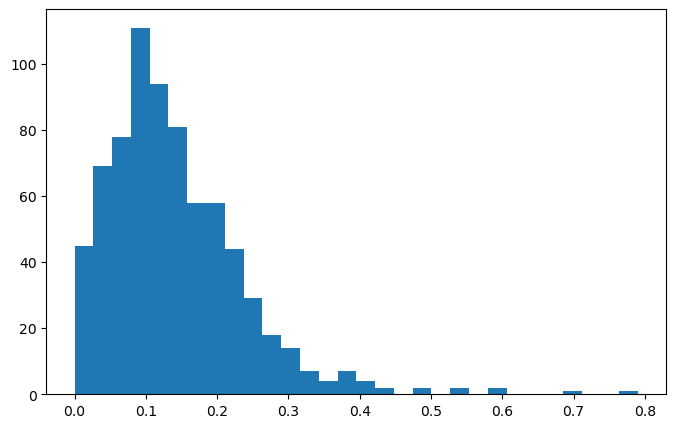

In [69]:
import matplotlib.pyplot as plt

N = agg_title.shape[0]



plt.figure(figsize=(8, 5))
plt.hist(
    agg_title["label1_score"].dropna(),
    bins=30
)

# Mean line
plt.axvline(
    mean_val,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_val:.3f}"
)

plt.xlabel("Empirical Score")
plt.ylabel("Number of hearings")

# Add N at bottom-left
plt.text(
    0.01, -0.15,
    f"N = {N}",
    transform=plt.gca().transAxes,
    fontsize=10
)

plt.tight_layout()
plt.show()

In [87]:
#df_original = pd.read_pickle(project_path("data","merged_hearings_roberta_predict.pkl"))
#df_original = pd.read_pickle(project_path("data","merged_hearings.pkl"))
df_original = pd.read_csv(project_path("data", "merged_metadata_df.csv"))

df_original.head()

C:\Users\USER\AppData\Local\Temp\ipykernel_10108\1233221630.py:3: DtypeWarning: Columns (33,34,37,38,39,40,41,44,45,77,78,79,85) have mixed types. Specify dtype option on import or set low_memory=False.
  df_original = pd.read_csv(project_path("data", "merged_metadata_df.csv"))


,congress_speech,committee_code2,title_speech,file_name,thomas_name,govtrack,speech,rownumber,gscore,powercmt,...,territorial.clause,war.powers,police.powers,vesting.clause,average_freq_ver1,average_freq_ver2,average_freq_ver3,average_freq_ver4,average_freq_ver5,class_const
0,105,HSGO,gulf war syndrome: to examine new studies sugg...,CHRG-105hhrg38711.txt,"Shays, Christopher",400370.0,Before we get to site: if a soldier was told ...,96,52.059444,0,...,"(0, 0.0)","(0, 0.0)","(0, 0.0)","(0, 0.0)",0,0.0,0.0,0.0,0.394549,1
1,105,HSGO,gulf war syndrome: to examine new studies sugg...,CHRG-105hhrg38711.txt,"Shays, Christopher",400370.0,"No, that is not the question I asked. I am al...",109,28.659586,0,...,"(0, 0.0)","(0, 0.0)","(0, 0.0)","(0, 0.0)",0,0.0,0.0,0.0,0.394549,1
2,105,HSGO,gulf war syndrome: to examine new studies sugg...,CHRG-105hhrg38711.txt,"Towns, Edolphus",400409.0,"Thank you very much. Dr. Custis, what enf...",91,28.123900,0,...,"(0, 0.0)","(0, 0.0)","(0, 0.0)","(0, 0.0)",0,0.0,0.0,0.0,0.394549,1
3,105,HSGO,gulf war syndrome: to examine new studies sugg...,CHRG-105hhrg38711.txt,"Shays, Christopher",400370.0,"I wish I had the three of you go first, and t...",221,39.428281,0,...,"(0, 0.0)","(0, 0.0)","(0, 0.0)","(0, 0.0)",0,0.0,0.0,0.0,0.394549,1
4,105,HSGO,gulf war syndrome: to examine new studies sugg...,CHRG-105hhrg38711.txt,"Shays, Christopher",400370.0,"Let me call on Mr. Sanders. Dr. Kizer, you wi...",113,21.450502,0,...,"(0, 0.0)","(0, 0.0)","(0, 0.0)","(0, 0.0)",0,0.0,0.0,0.0,0.394549,1


In [94]:
cols = [col for col in df_original.columns if 'empirical' in col]

In [95]:
cols

[]

NameError: name 'N' is not defined

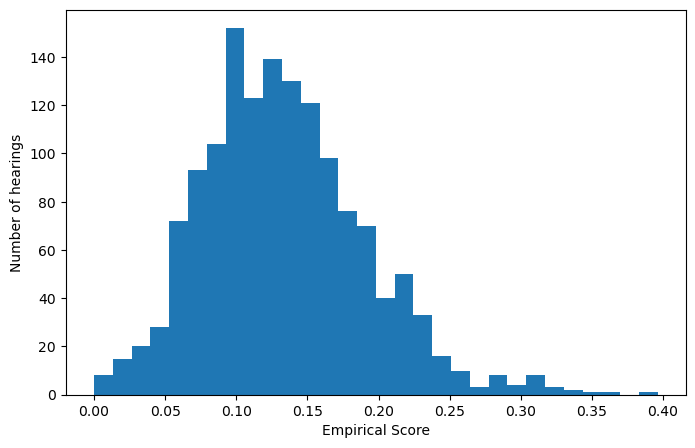

In [31]:
# Make sure pred_label_id is numeric
df_original["predictions"] = pd.to_numeric(df_original["predictions"], errors="coerce")

# ---------- Aggregate score per title_hearings ----------
agg_title_original = (
    df_original
    .groupby("title", dropna=False)
    .agg(
        total_sentences=("target_sentence", "size"),
        label1_sentences=("predictions", lambda s: (s == 1).sum()),
    )
    .reset_index()
)

agg_title_original["label1_score"] = agg_title_original["label1_sentences"] / agg_title_original["total_sentences"]
    

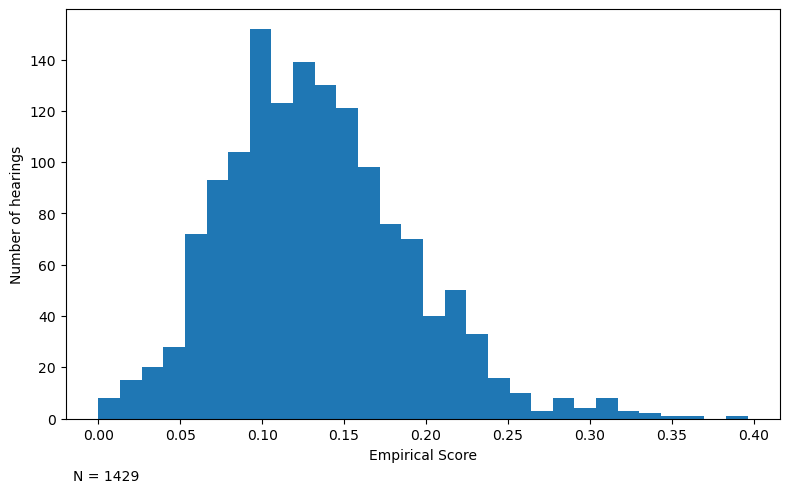

In [33]:
N = agg_title_original.shape[0]

plt.figure(figsize=(8, 5))
plt.hist(
    agg_title_original["label1_score"].dropna(),
    bins=30
)

plt.xlabel("Empirical Score")
plt.ylabel("Number of hearings")

# Add N at bottom-left
plt.text(
    0.01, -0.15,
    f"N = {N}",
    transform=plt.gca().transAxes,
    fontsize=10
)

plt.tight_layout()
plt.show()

In [35]:
agg_title_original

,title,total_sentences,label1_sentences,label1_score
0,18f and U.s. Digital Service Oversight',349,22,0.063037
1,1988 to 2016: Vetsnet to Vbms; Billions Spent...,415,63,0.151807
2,2015 TAX FILING SEASON AND GENERAL OPERATIONS...,732,99,0.135246
3,21ST CENTURY ENERGY MARKETS: HOW THE CHANGING...,578,101,0.174740
4,A Casino in Every Smartphone: Law Enforcement...,630,61,0.096825
...,...,...,...,...
1424,YEAR ANNIVERSARY AFTER ENACTMENT: IMPLEMENTATI...,765,77,0.100654
1425,"YEAR REVIEW OF COSTS AND BENEFITS""",213,47,0.220657
1426,YEAR REVIEW OF COSTS AND BENEFITS',332,93,0.280120
1427,ZIMBABWE RELATIONS',502,77,0.153386


In [76]:

agg_title.columns

Index(['title_hearings', 'total_sentences', 'label1_sentences',
       'empirical_score'],
      dtype='object')

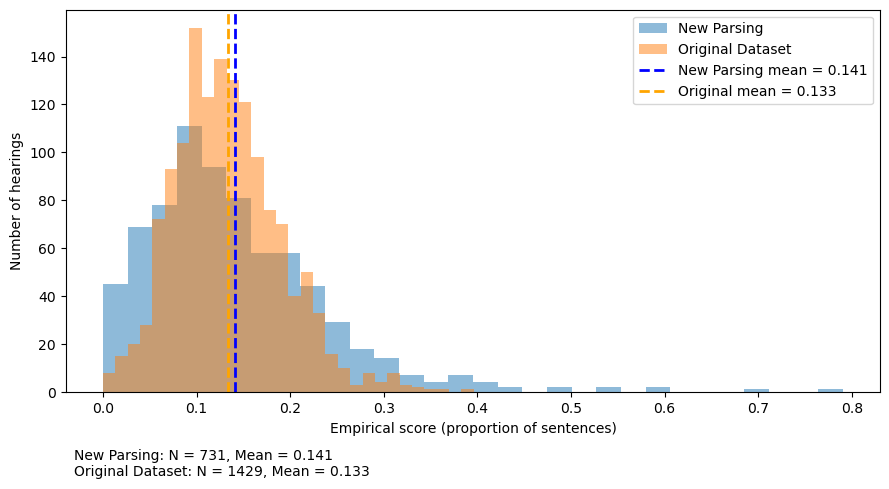

In [70]:
agg_title = agg_title.rename(columns={"label1_score": "empirical_score"})
agg_title_original = agg_title_original.rename(columns={"label1_score": "empirical_score"})

import matplotlib.pyplot as plt

col = "empirical_score"

# clean series
new = agg_title[col].dropna()
orig = agg_title_original[col].dropna()

# sample sizes (rows)
N_new = agg_title.shape[0]
N_orig = agg_title_original.shape[0]

# means
mean_new = new.mean()
mean_orig = orig.mean()

plt.figure(figsize=(9, 5))

# overlaid histograms
plt.hist(new, bins=30, alpha=0.5, label="New Parsing")
plt.hist(orig, bins=30, alpha=0.5, label="Original Dataset")

# Mean lines with DIFFERENT COLORS
plt.axvline(
    mean_new,
    linestyle="--",
    linewidth=2,
    color="blue",
    label=f"New Parsing mean = {mean_new:.3f}"
)

plt.axvline(
    mean_orig,
    linestyle="--",
    linewidth=2,
    color="orange",
    label=f"Original mean = {mean_orig:.3f}"
)

plt.xlabel("Empirical score (proportion of sentences)")
plt.ylabel("Number of hearings")

# N + mean annotation
plt.text(
    0.01, -0.22,
    f"New Parsing: N = {N_new}, Mean = {mean_new:.3f}\n"
    f"Original Dataset: N = {N_orig}, Mean = {mean_orig:.3f}",
    transform=plt.gca().transAxes,
    fontsize=10
)

plt.legend()
plt.tight_layout()
plt.show()


In [78]:
import re

agg_title = agg_title.rename(columns={"title_hearings": "title"})

def normalize_title(s):
    if pd.isna(s):
        return ""
    s = s.lower()
    s = re.sub(r"[^\w\s]", "", s)   # remove punctuation
    s = re.sub(r"\s+", " ", s)      # collapse whitespace
    return s.strip()

agg_title["title_norm"] = agg_title["title"].apply(normalize_title)
agg_title_original["title_norm"] = agg_title_original["title"].apply(normalize_title)


In [79]:
exact_match = agg_title.merge(
    agg_title_original,
    on="title_norm",
    suffixes=("_new", "_orig")
)

coverage = len(exact_match) / min(len(agg_title), len(agg_title_original))
print(f"Exact match coverage: {coverage:.2%}")


Exact match coverage: 0.14%


In [81]:
import difflib

orig_titles = agg_title_original["title_norm"].tolist()

def fuzzy_match_difflib(title, cutoff=0.85):
    matches = difflib.get_close_matches(
        title,
        orig_titles,
        n=1,
        cutoff=cutoff
    )
    return matches[0] if matches else None

agg_title["title_fuzzy"] = agg_title["title_norm"].apply(fuzzy_match_difflib)


In [83]:
# rows in new that did NOT match exactly
unmatched_new = agg_title[
    ~agg_title["title_norm"].isin(exact_match["title_norm"])
].copy()
matched = pd.concat(
    [exact_match, fuzzy_match_df],
    ignore_index=True
)

fuzzy_match_df = unmatched_new.merge(
    agg_title_original,
    left_on="title_fuzzy",     # returned by difflib
    right_on="title_norm",
    suffixes=("_new", "_orig")
)


In [84]:
matched = pd.concat(
    [exact_match, fuzzy_match_df],
    ignore_index=True
)

print(f"Matched hearings: {len(matched)}")

matched[[
    "hearing_title_new",
    "hearing_title_orig"
]].sample(10, random_state=42)


Matched hearings: 15


KeyError: "None of [Index(['hearing_title_new', 'hearing_title_orig'], dtype='object')] are in the [columns]"

In [ ]:
mae = (matched["empirical_score_new"] -
       matched["empirical_score_orig"]).abs().mean()

corr = matched["empirical_score_new"].corr(
    matched["empirical_score_orig"]
)

print(f"MAE = {mae:.3f}")
print(f"Correlation = {corr:.3f}")


In [ ]:
import numpy as np

mae = np.mean(
    np.abs(matched["empirical_score_new"] - matched["empirical_score_orig"])
)

print(f"MAE = {mae:.3f}")


plt.figure(figsize=(6, 6))

plt.scatter(
    matched["empirical_score_orig"],
    matched["empirical_score_new"],
    alpha=0.6
)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("Original empirical score")
plt.ylabel("New parsing empirical score")
plt.title("Per-hearing score comparison")

plt.tight_layout()
plt.show()
